[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/vonKleve/csci-e222-final-project/blob/master/99-comparative-analysis.ipynb)

# Comparative Analysis: Bio_ClinicalBERT vs. MedGemma-4B

## Description
This notebook conducts a comparative analysis between traditional Encoder-based architectures (BERT) and modern Decoder-based Large Language Models (Gemma) on two specialized medical tasks:
1. **Medical Named Entity Recognition (NER)** using the `MedMentions` dataset.
2. **Medical Multiple-Choice QA** using the `MedQA` dataset.

### The Models
We will evaluate the following models previously published to the Hugging Face Hub:
* **NER (Classification):** `alexd063/bio-clinicalbert-finetuned-medmentions-v1`
* **NER (Generative):** `alexd063/gemma4bit-finetuned-medmentions`
* **QA (Classification):** `alexd063/bio-clinicalbert-finetuned-medqa`
* **QA (Generative):** `alexd063/gemma4bit-finetuned-medqa`

### Architecture Paradigms
* **BERT** treats NER as *Token Classification* and QA as *Sequence Classification* (outputting logits for 4 options).
* **Gemma** treats everything as *Text-to-Text Generation*, requiring strict prompt formatting and parsing of the output string.

In [1]:
%%capture
# !pip install --upgrade transformers datasets evaluate scikit-learn matplotlib seaborn accelerate bitsandbytes peft
!pip install --upgrade transformers bitsandbytes accelerate trl unsloth datasets seqeval evaluate

In [2]:
import os
# Suppress all tqdm/HuggingFace progress bars before any library is imported
os.environ["TQDM_DISABLE"] = "1"
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
os.environ["HF_DATASETS_DISABLE_PROGRESS_BARS"] = "1"

In [3]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

from datasets import load_dataset
from transformers import (
    pipeline,
    AutoTokenizer,
    AutoModelForMultipleChoice,
)
from unsloth import FastLanguageModel

# Global Configuration
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Using device: {DEVICE}")

/tmp/ipykernel_1137/3155785487.py:15: UserWarning: WARNING: Unsloth should be imported before transformers to ensure all optimizations are applied. Your code may run slower or encounter memory issues without these optimizations.

Please restructure your imports with 'import unsloth' at the top of your file.
  from unsloth import FastLanguageModel


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


Unable to import `torchao` Tensor objects. This may affect loading checkpoints serialized with `torchao`
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Using device: cuda


In [4]:
import os
os.environ["TQDM_DISABLE"] = "1"

from transformers.utils import logging as hf_logging
hf_logging.set_verbosity_error()

from datasets import disable_progress_bars
disable_progress_bars()

from huggingface_hub.utils import disable_progress_bars as hub_disable_progress_bars
hub_disable_progress_bars()

---
## Part 1: Medical Named Entity Recognition (MedMentions)
We will run a qualitative side-by-side comparison. For BERT, we use the standard Hugging Face `TokenClassification` pipeline. For Gemma, we construct a prompt and parse the generative output.

In [5]:
print("Loading MedMentions Dataset...")
ner_dataset = load_dataset("Ben10x/MedMentions-MTI881-NER", split="test")

# 1. Load BERT NER Model
print("Loading BERT NER...")
bert_ner_id = "alexd063/bio-clinicalbert-finetuned-medmentions-v1"
bert_ner_pipe = pipeline("ner", model=bert_ner_id, aggregation_strategy="simple",
                         device=0 if DEVICE=="cuda" else -1)

# 2. Load Gemma NER Model (Unsloth — matches training environment)
print("Loading Gemma NER...")
gemma_ner_id = "alexd063/gemma4bit-finetuned-medmentions"
gemma_ner_model, gemma_ner_tokenizer = FastLanguageModel.from_pretrained(
    model_name=gemma_ner_id,
    max_seq_length=512,
    load_in_4bit=True,
)
FastLanguageModel.for_inference(gemma_ner_model)
print("NER models loaded.")

Loading MedMentions Dataset...
Loading BERT NER...
Loading Gemma NER...
==((====))==  Unsloth 2025.11.1: Fast Gemma3 patching. Transformers: 4.57.2.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.494 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: Gemma3 does not support SDPA - switching to fast eager.
NER models loaded.


In [6]:
def compare_ner(sample_idx=0):
    sample = ner_dataset[sample_idx]
    text = " ".join(sample["tokens"])

    print("="*80)
    print(" INPUT TEXT:")
    print(text)
    print("="*80)

    # --- BERT INFERENCE ---
    bert_results = bert_ner_pipe(text)
    bert_entities = [f"{ent['word']} ({ent['entity_group']})" for ent in bert_results]

    print("\n[Bio_ClinicalBERT Predictions]:")
    if bert_entities:
        print(", ".join(bert_entities))
    else:
        print("No entities found.")

    # --- GEMMA INFERENCE ---
    instruction = "Extract medical entities from the following text and label each token with its NER tag."
    prompt = (
        f"### Instruction:\n{instruction}\n\n"
        f"### Input:\n{text}\n\n"
        f"### Response:\n"
    )

    inputs = gemma_ner_tokenizer(prompt, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        outputs = gemma_ner_model.generate(
            **inputs,
            max_new_tokens=150,
            do_sample=False
        )

    decoded = gemma_ner_tokenizer.decode(outputs[0], skip_special_tokens=True)
    gemma_response = decoded.split("### Response:\n")[-1].strip()

    print("\n[MedGemma-4B Predictions]:")
    print(gemma_response)
    print("="*80 + "\n")

# Test on 3 samples
for i in range(3):
    compare_ner(sample_idx=i)

 INPUT TEXT:
Here , the role of Mnk1 ( mitogen - activated protein kinase - interacting kinase 1 ) in cardiac remodeling was clarified .

[Bio_ClinicalBERT Predictions]:
mnk1 (T103), mitogen - activated protein kinase - interacting kinase 1 (T103), cardiac remodeling (T038)

[MedGemma-4B Predictions]:
Here: O, ,: O, the: O, role: O, of: O, Mnk1: B-T017, (: O, mitogen: B-T103, -: I-T103, activated: I-T103, protein: I-T103, kinase: I-T103, -: I-T103, interacting: I-T103, kinase: I-T103, 1: I-T103, ): O, in: O, cardiac: B-T038, remodeling: I-T038, was: O, clarified: O,

 INPUT TEXT:
Abnormal α - synuclein ( α - syn ) accumulation in the CNS may underlie neuronal cell and synaptic dysfunction leading to motor and cognitive deficits in synucleinopathies including Parkinson 's disease ( PD ) and Dementia with Lewy Bodies ( DLB ) .

[Bio_ClinicalBERT Predictions]:
abnormal (T033), α - synuclein (T103), α - syn (T103), accumulation (T033), ##ns (T017), ne (T017), ##uronal cell (T017), s (T038)

### 1b. NER Quantitative Evaluation (100 Test Samples)
A simple parser reconstructs word-level BIO tags from BERT's pipeline span output and Gemma's `Token: Tag, ...` generative output. We run seqeval F1 on 100 test samples for both models.

In [8]:
# -----------------------------------------------------------------------
#                             WARNING
# THIS CELL WILL TAKE TIME TO RUN, 10+ MINS
# TO REDUCE THE AMOUNT OF TIME IT TAKES - CHANGE NER_EVAL_SAMPLES VALUE
# -----------------------------------------------------------------------
from seqeval.metrics import (
    f1_score as seqeval_f1,
    precision_score as seqeval_precision,
    recall_score as seqeval_recall,
)

NER_EVAL_SAMPLES = 30
ner_eval_subset = ner_dataset.select(range(NER_EVAL_SAMPLES))

def reconstruct_word_tags(tokens, ner_pipe_output):
    """Map pipeline aggregated-span output back to word-level BIO tags."""
    text = " ".join(tokens)
    char_to_word = {}
    pos = 0
    for idx, tok in enumerate(tokens):
        for c in range(len(tok)):
            char_to_word[pos + c] = idx
        pos += len(tok) + 1

    pred_tags = ["O"] * len(tokens)
    for ent in ner_pipe_output:
        entity_type = ent["entity_group"]
        start, end = ent["start"], ent["end"]
        covered, seen = [], set()
        for c in range(start, min(end, len(text))):
            if c in char_to_word and char_to_word[c] not in seen:
                covered.append(char_to_word[c])
                seen.add(char_to_word[c])
        for i, widx in enumerate(covered):
            pred_tags[widx] = f"B-{entity_type}" if i == 0 else f"I-{entity_type}"
    return pred_tags

def parse_gemma_ner_output(generated_text, expected_tokens):
    """Parse 'Token: Tag, Token: Tag, ...' generative output to word-level BIO tags."""
    part = generated_text.split("### Response:")[-1] if "### Response:" in generated_text else generated_text
    part = part.split("<eos>")[0].split("<|endoftext|>")[0].strip()
    parsed = {}
    for pair in part.split(","):
        pair = pair.strip()
        if ": " in pair:
            tok, tag = pair.split(": ", 1)
            parsed[tok.strip()] = tag.strip()
    return [parsed.get(tok, "O") for tok in expected_tokens]

# ── BERT NER ──
bert_ner_true, bert_ner_pred = [], []
for sample in ner_eval_subset:
    tokens, true_tags = sample["tokens"], sample["ner_tags"]
    pipe_out = bert_ner_pipe(" ".join(tokens))
    pred_tags = reconstruct_word_tags(tokens, pipe_out)
    bert_ner_true.append(true_tags)
    bert_ner_pred.append(pred_tags)

bert_ner_f1 = seqeval_f1(bert_ner_true, bert_ner_pred)
bert_ner_precision = seqeval_precision(bert_ner_true, bert_ner_pred)
bert_ner_recall = seqeval_recall(bert_ner_true, bert_ner_pred)
print(f"Bio_ClinicalBERT NER ({NER_EVAL_SAMPLES} samples) | "
      f"P={bert_ner_precision:.3f}  R={bert_ner_recall:.3f}  F1={bert_ner_f1:.3f}")

# ── Gemma NER ──
_ner_instruction = ("Extract medical entities from the following text "
                    "and label each token with its NER tag.")
gemma_ner_true, gemma_ner_pred = [], []
for sample in ner_eval_subset:
    tokens, true_tags = sample["tokens"], sample["ner_tags"]
    text = " ".join(tokens)
    prompt = (f"### Instruction:\n{_ner_instruction}\n\n"
              f"### Input:\n{text}\n\n### Response:\n")
    inputs = gemma_ner_tokenizer(
        prompt, return_tensors="pt", truncation=True, max_length=512
    ).to(DEVICE)
    with torch.no_grad():
        out = gemma_ner_model.generate(
            **inputs, max_new_tokens=256, do_sample=False,
            pad_token_id=gemma_ner_tokenizer.eos_token_id
        )
    decoded = gemma_ner_tokenizer.decode(out[0], skip_special_tokens=True)
    pred_tags = parse_gemma_ner_output(decoded, tokens)
    if len(pred_tags) != len(true_tags):
        pred_tags = ["O"] * len(true_tags)
    gemma_ner_true.append(true_tags)
    gemma_ner_pred.append(pred_tags)

gemma_ner_f1 = seqeval_f1(gemma_ner_true, gemma_ner_pred)
gemma_ner_precision = seqeval_precision(gemma_ner_true, gemma_ner_pred)
gemma_ner_recall = seqeval_recall(gemma_ner_true, gemma_ner_pred)
print(f"MedGemma-4B NER ({NER_EVAL_SAMPLES} samples)     | "
      f"P={gemma_ner_precision:.3f}  R={gemma_ner_recall:.3f}  F1={gemma_ner_f1:.3f}")


Bio_ClinicalBERT NER (30 samples) | P=0.529  R=0.658  F1=0.586
MedGemma-4B NER (30 samples)     | P=0.255  R=0.252  F1=0.253


---
## Part 2: Medical Question Answering (MedQA)
We will evaluate both models on a subset of the MedQA test split to calculate quantitative accuracy.

* **BERT Pipeline:** We manually feed `(Question, Option)` pairs into the model and apply softmax to the 4 output logits.
* **Gemma Pipeline:** We format the question as a prompt and restrict generation to exactly 2 tokens (the answer letter + EOS).

In [13]:
print("Loading MedQA Dataset...")
qa_dataset = load_dataset("GBaker/MedQA-USMLE-4-options", split="test")
qa_subset = qa_dataset.select(range(200)) # Evaluate on 200 samples

# 1. Load BERT QA Model
print("Loading BERT QA...")
bert_qa_id = "alexd063/bio-clinicalbert-finetuned-medqa"
bert_qa_tokenizer = AutoTokenizer.from_pretrained(bert_qa_id)
bert_qa_model = AutoModelForMultipleChoice.from_pretrained(bert_qa_id).to(DEVICE)
bert_qa_model.eval()

Loading MedQA Dataset...
Loading BERT QA...


BertForMultipleChoice(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(28996, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, ele

In [14]:
# 2. Load Gemma QA Model (Unsloth — matches training environment)
print("Loading Gemma QA...")
gemma_qa_id = "alexd063/gemma4bit-finetuned-medqa"
gemma_qa_model, gemma_qa_tokenizer = FastLanguageModel.from_pretrained(
    model_name=gemma_qa_id,
    max_seq_length=1024,
    load_in_4bit=True,
)
FastLanguageModel.for_inference(gemma_qa_model)
print("Models loaded successfully.")

Loading Gemma QA...
==((====))==  Unsloth 2025.11.1: Fast Gemma3 patching. Transformers: 4.57.2.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.494 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: Gemma3 does not support SDPA - switching to fast eager.
Models loaded successfully.


In [16]:
# -----------------------------------------------------------------------
#                             WARNING
# THIS CELL WILL TAKE TIME TO RUN, 10+ MINS
# TO REDUCE THE AMOUNT OF TIME IT TAKES - CHANGE qa_subset RANDOM SUPPORT
# -----------------------------------------------------------------------
true_labels = []
bert_predictions = []
gemma_predictions = []

print("Running Inference on QA Subset...")

for idx, sample in enumerate(tqdm(qa_subset)):
    question = sample["question"]
    opts = sample["options"]
    answer_idx = sample["answer_idx"].upper()
    true_labels.append(answer_idx)

    # -------------------------
    # 1. BERT
    # -------------------------
    choices = [opts.get('A',''), opts.get('B',''), opts.get('C',''), opts.get('D','')]
    # Format for MultipleChoice: [[Q, A], [Q, B], [Q, C], [Q, D]]
    bert_inputs = bert_qa_tokenizer(
        [[question, c] for c in choices],
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=512
    )
    # Add batch dimension: (1, 4, seq_length)
    bert_inputs = {k: v.unsqueeze(0).to(DEVICE) for k, v in bert_inputs.items()}

    with torch.no_grad():
        bert_outputs = bert_qa_model(**bert_inputs)
        predicted_class = torch.argmax(bert_outputs.logits, dim=1).item()

    # Map index 0-3 back to A-D
    bert_predictions.append(["A", "B", "C", "D"][predicted_class])

    # -------------------------
    # 2. Gemma
    # -------------------------
    instruction = "Answer the following multiple-choice medical question. Provide only the letter of the correct option (A, B, C, or D)."
    options_text = f"A: {opts.get('A', '')}\nB: {opts.get('B', '')}\nC: {opts.get('C', '')}\nD: {opts.get('D', '')}"

    prompt = (
        f"### Instruction:\n{instruction}\n\n"
        f"### Question:\n{question}\n\n"
        f"### Options:\n{options_text}\n\n"
        f"### Answer:\n"
    )

    gemma_inputs = gemma_qa_tokenizer([prompt], return_tensors="pt").to(DEVICE)

    with torch.no_grad():
        gemma_outputs = gemma_qa_model.generate(
            **gemma_inputs,
            max_new_tokens=2,
            do_sample=False,
            pad_token_id=gemma_qa_tokenizer.eos_token_id
        )

    decoded = gemma_qa_tokenizer.batch_decode(gemma_outputs, skip_special_tokens=True)[0]
    gemma_pred = decoded.split("### Answer:\n")[-1].strip()[:1].upper()

    if gemma_pred not in ["A", "B", "C", "D"]:
        gemma_pred = "A"

    gemma_predictions.append(gemma_pred)

    if idx % 10 == 0:
        print(f"Processed {idx}/{len(qa_subset)} samples.")

print("\nInference done.")

Running Inference on QA Subset...
Processed 0/200 samples.
Processed 10/200 samples.
Processed 20/200 samples.
Processed 30/200 samples.
Processed 40/200 samples.
Processed 50/200 samples.
Processed 60/200 samples.
Processed 70/200 samples.
Processed 80/200 samples.
Processed 90/200 samples.
Processed 100/200 samples.
Processed 110/200 samples.
Processed 120/200 samples.
Processed 130/200 samples.
Processed 140/200 samples.
Processed 150/200 samples.
Processed 160/200 samples.
Processed 170/200 samples.
Processed 180/200 samples.
Processed 190/200 samples.

Inference done.


In [17]:
# ==========================================
# QA Scoring
# ==========================================
bert_qa_acc  = accuracy_score(true_labels, bert_predictions)
gemma_qa_acc = accuracy_score(true_labels, gemma_predictions)
bert_qa_f1   = f1_score(true_labels, bert_predictions,  average='macro', labels=['A','B','C','D'])
gemma_qa_f1  = f1_score(true_labels, gemma_predictions, average='macro', labels=['A','B','C','D'])

print("=" * 55)
print(f"{'Model':<25} {'Accuracy':>10} {'Macro F1':>10}")
print("=" * 55)
print(f"{'Bio_ClinicalBERT':<25} {bert_qa_acc:>10.3f} {bert_qa_f1:>10.3f}")
print(f"{'MedGemma-4B':<25} {gemma_qa_acc:>10.3f} {gemma_qa_f1:>10.3f}")
print(f"{'Random baseline (0.25)':<25} {0.250:>10.3f} {'--':>10}")
print("=" * 55)

print("\nBio_ClinicalBERT per-option report:")
print(classification_report(true_labels, bert_predictions, labels=['A','B','C','D'], zero_division=0))
print("\nMedGemma-4B per-option report:")
print(classification_report(true_labels, gemma_predictions, labels=['A','B','C','D'], zero_division=0))


Model                       Accuracy   Macro F1
Bio_ClinicalBERT               0.300      0.301
MedGemma-4B                    0.565      0.564
Random baseline (0.25)         0.250         --

Bio_ClinicalBERT per-option report:
              precision    recall  f1-score   support

           A       0.40      0.29      0.33        49
           B       0.26      0.32      0.29        47
           C       0.33      0.33      0.33        55
           D       0.25      0.27      0.25        49

    accuracy                           0.30       200
   macro avg       0.31      0.30      0.30       200
weighted avg       0.31      0.30      0.30       200


MedGemma-4B per-option report:
              precision    recall  f1-score   support

           A       0.57      0.59      0.58        49
           B       0.58      0.66      0.62        47
           C       0.57      0.53      0.55        55
           D       0.53      0.49      0.51        49

    accuracy                    

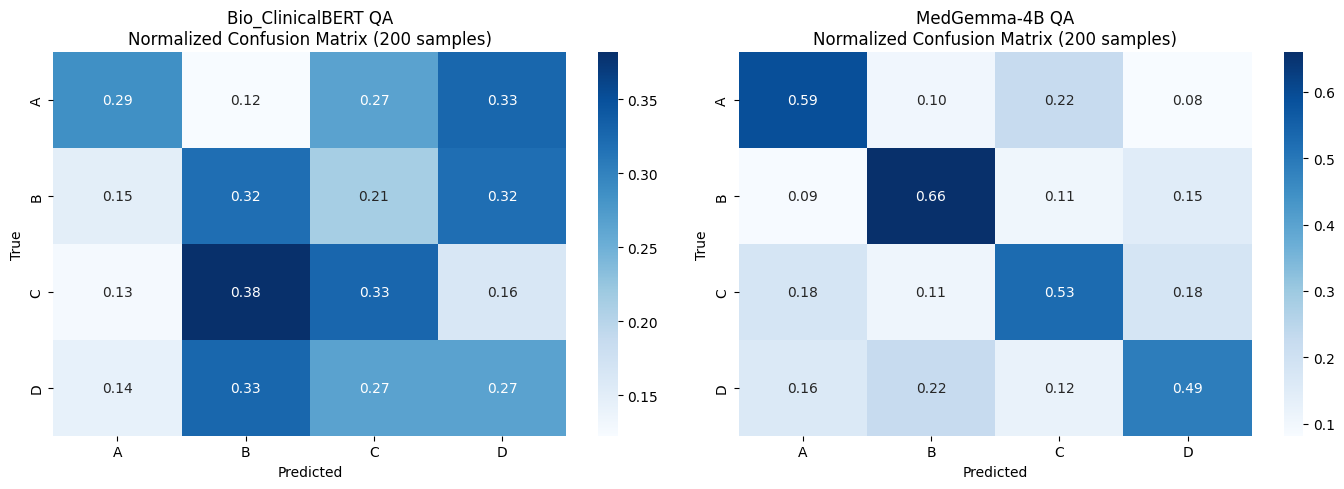

Saved: qa_comparison_confusion_matrices.png


In [18]:
# ==========================================
# QA Side-by-Side Confusion Matrices
# ==========================================
option_names = ['A', 'B', 'C', 'D']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, preds, title in zip(
        axes,
        [bert_predictions, gemma_predictions],
        ['Bio_ClinicalBERT QA', 'MedGemma-4B QA']):
    cm = confusion_matrix(true_labels, preds, labels=option_names, normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=option_names, yticklabels=option_names, ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(f'{title}\nNormalized Confusion Matrix (200 samples)')

plt.tight_layout()
plt.savefig('qa_comparison_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: qa_comparison_confusion_matrices.png")


---
## Summary: All Metrics (Comparative)

In [19]:
# ==========================================
# Summary Table — All Metrics
# ==========================================
summary = {
    'Model':         ['Bio_ClinicalBERT', 'MedGemma-4B'],
    'NER Precision': [round(bert_ner_precision, 3), round(gemma_ner_precision, 3)],
    'NER Recall':    [round(bert_ner_recall, 3),    round(gemma_ner_recall, 3)],
    'NER F1':        [round(bert_ner_f1, 3),        round(gemma_ner_f1, 3)],
    'QA Accuracy':   [round(bert_qa_acc, 3),        round(gemma_qa_acc, 3)],
    'QA Macro F1':   [round(bert_qa_f1, 3),         round(gemma_qa_f1, 3)],
}
df_summary = pd.DataFrame(summary).set_index('Model')
print(df_summary.to_markdown())
print()
try:
    from IPython.display import display
    display(df_summary)
except Exception:
    pass


| Model            |   NER Precision |   NER Recall |   NER F1 |   QA Accuracy |   QA Macro F1 |
|:-----------------|----------------:|-------------:|---------:|--------------:|--------------:|
| Bio_ClinicalBERT |           0.529 |        0.658 |    0.586 |         0.3   |         0.301 |
| MedGemma-4B      |           0.255 |        0.252 |    0.253 |         0.565 |         0.564 |



,NER Precision,NER Recall,NER F1,QA Accuracy,QA Macro F1
Model,,,,,
Bio_ClinicalBERT,0.529,0.658,0.586,0.300,0.301
MedGemma-4B,0.255,0.252,0.253,0.565,0.564


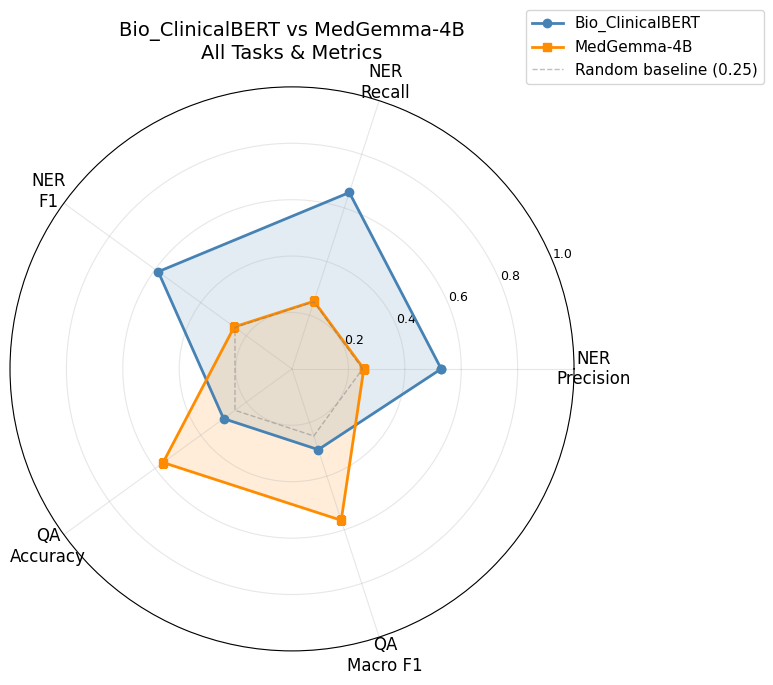

Saved: comparative_radar_chart.png


In [20]:
# ==========================================
# Radar / Spider Chart — All Metrics
# ==========================================
import numpy as np

categories = ['NER\nPrecision', 'NER\nRecall', 'NER\nF1', 'QA\nAccuracy', 'QA\nMacro F1']
N = len(categories)

bert_vals  = [bert_ner_precision,  bert_ner_recall,  bert_ner_f1,  bert_qa_acc,  bert_qa_f1]
gemma_vals = [gemma_ner_precision, gemma_ner_recall, gemma_ner_f1, gemma_qa_acc, gemma_qa_f1]
random_val = 0.25

angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist() + [0]
bert_plot  = bert_vals  + bert_vals[:1]
gemma_plot = gemma_vals + gemma_vals[:1]
rand_plot  = [random_val] * (N + 1)

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

ax.plot(angles, bert_plot,  'o-', linewidth=2, color='steelblue',  label='Bio_ClinicalBERT')
ax.fill(angles, bert_plot,  alpha=0.15, color='steelblue')
ax.plot(angles, gemma_plot, 's-', linewidth=2, color='darkorange', label='MedGemma-4B')
ax.fill(angles, gemma_plot, alpha=0.15, color='darkorange')
ax.plot(angles, rand_plot,  '--', linewidth=1, color='gray', alpha=0.5, label='Random baseline (0.25)')

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=12)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], size=9)
ax.grid(True, alpha=0.3)
ax.set_title('Bio_ClinicalBERT vs MedGemma-4B\nAll Tasks & Metrics', size=14, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=11)

plt.tight_layout()
plt.savefig('comparative_radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: comparative_radar_chart.png")
